In [1]:
from datasets import load_dataset
from PIL import Image
import io

dataset = load_dataset("lmarena-ai/VisionArena-Chat", trust_remote_code=True, streaming=True) # , split="train" 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
battledataset = load_dataset("lmarena-ai/VisionArena-Battle", trust_remote_code=True, streaming=True) # , split="train"
data = next(iter(battledataset['train'])) 

In [ ]:
benchdataset = load_dataset("lmarena-ai/vision-arena-bench-v0.1", trust_remote_code=True, streaming=True) # , split="train" 
data = next(iter(benchdataset['train']))
data

{'question_id': '807c1d45bfc240c2bba59ff3ac97b441',
 'cluster_name': 'Painting Analysis and Interpretation',
 'turns': [[{'content': 'Considering the image, explain what would have happened in a modern scenario?'}]],
 'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=1023x689>]}

In [13]:
show_examples(benchdataset)


Example 1
question_id: 807c1d45bfc240c2bba59ff3ac97b441
cluster_name: Painting Analysis and Interpretation
turns: [[{'content': 'Considering the image, explain what would have happened in a modern scenario?'}]]

Images (1):


TypeError: 'PngImageFile' object is not subscriptable

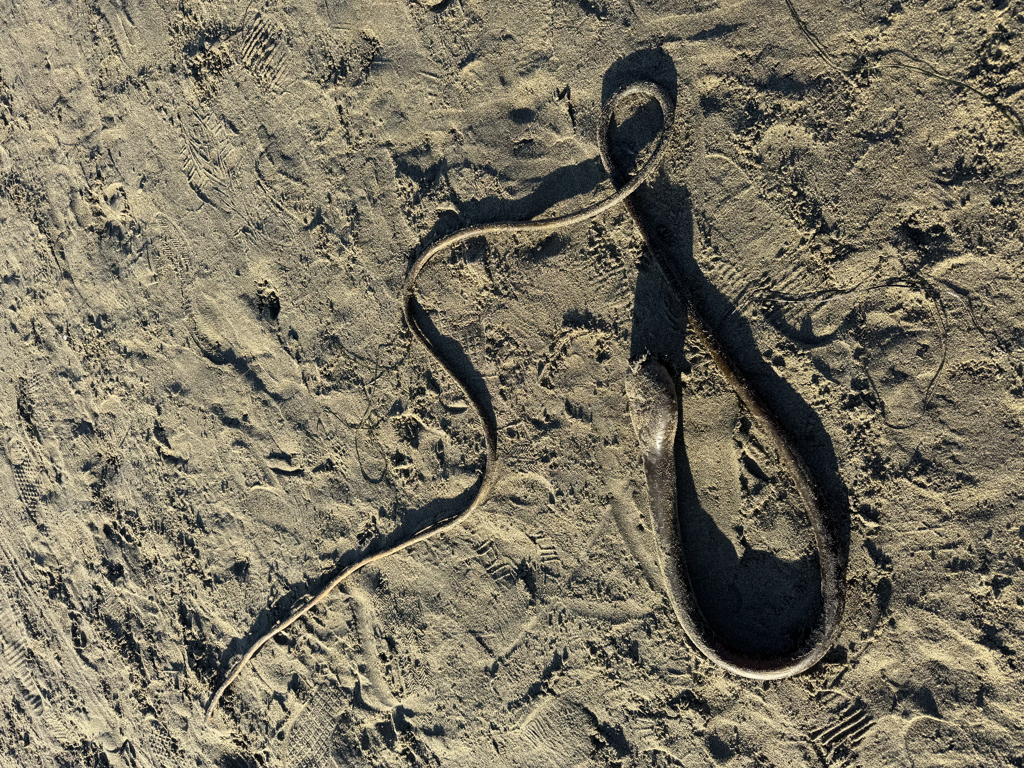

{'conversation_id': 'cbda71fbc23545faaa3238e6f4177ef6', 'model': 'gpt-4o-mini-2024-07-18', 'num_turns': 2, 'conversation': [[{'content': "What's this?", 'role': 'user'}], [{'content': 'The object in the image appears to be a snake, likely resting or moving along a sandy surface. It has a long, slender body, typical of many snake species. If you need more specific information about the type of snake or its behavior, please let me know!', 'role': 'assistant'}], [{'content': 'It is not a snake, it is some kind of seaweed on the beach ', 'role': 'user'}], [{'content': 'Thanks for clarifying! It does resemble some types of seaweed or marine vegetation that can wash up on beaches. These can often have elongated, snake-like shapes. If you have any more questions about it or need information on marine life, feel free to ask!', 'role': 'assistant'}]], 'language': 'English', 'user_id': 90768, 'tstamp': 1725345810.4983, 'is_preset': False, 'preset_dataset': 'N/A', 'categories': {'captioning': Tru

In [ ]:
from IPython.display import display

# Get first example - handle different image formats
images = data['images']
img_data = images[0]

# Handle different image formats
if isinstance(img_data, Image.Image):
    img = img_data
elif isinstance(img_data, dict) and 'bytes' in img_data:
    img = Image.open(io.BytesIO(img_data['bytes']))
elif isinstance(img_data, bytes):
    img = Image.open(io.BytesIO(img_data))
elif isinstance(img_data, dict) and 'path' in img_data:
    img = Image.open(img_data['path'])
else:
    print(f"Unsupported image format: {type(img_data)}")
    img = None

if img:
    display(img)  # Display image in notebook (instead of img.show() which opens external viewer)
print({k: v for k, v in data.items() if k != "images"})


Example 1
conversation_id: cbda71fbc23545faaa3238e6f4177ef6
model: gpt-4o-mini-2024-07-18
num_turns: 2
conversation:
  [{'content': "What's this?", 'role': 'user'}]
  [{'content': 'The object in the image appears to be a snake, likely resting or moving along a sandy surface. It has a long, slender body, typical of many snake species. If you need more specific information about the type of snake or its behavior, please let me know!', 'role': 'assistant'}]
  [{'content': 'It is not a snake, it is some kind of seaweed on the beach ', 'role': 'user'}]
  [{'content': 'Thanks for clarifying! It does resemble some types of seaweed or marine vegetation that can wash up on beaches. These can often have elongated, snake-like shapes. If you have any more questions about it or need information on marine life, feel free to ask!', 'role': 'assistant'}]
language: English
user_id: 90768
tstamp: 1725345810.4983
is_preset: False
preset_dataset: N/A
categories: {'captioning': True, 'code': False, 'creat

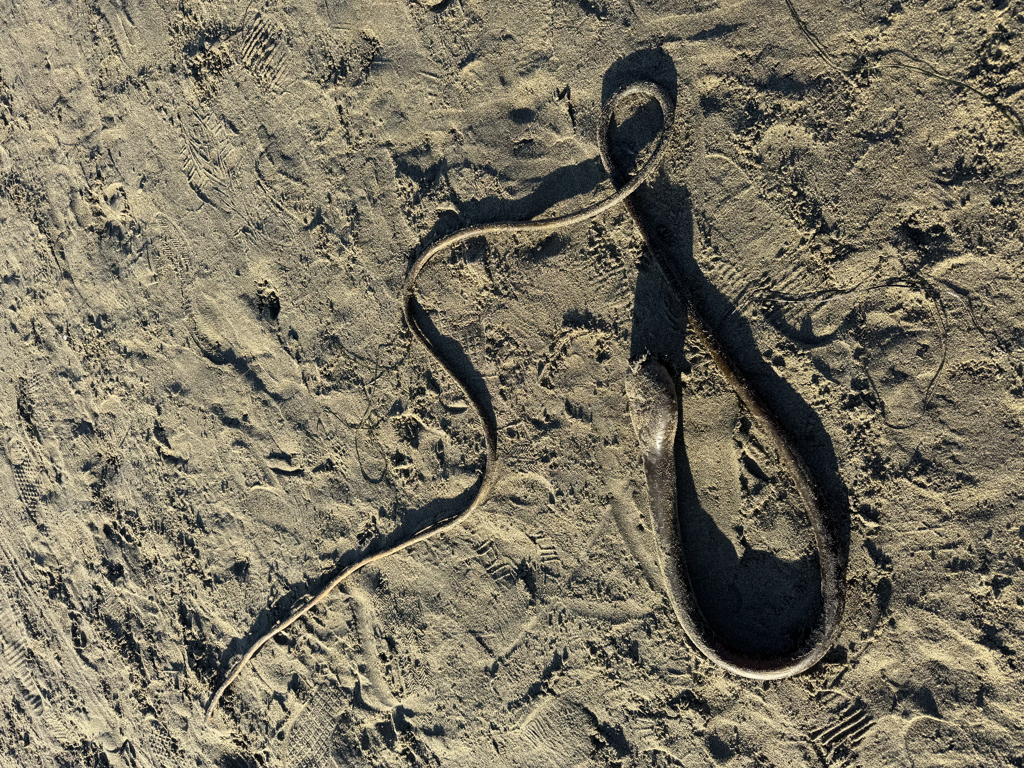

  Image 1 size: (1024, 768)



Example 2
conversation_id: d476d1a3653541b2b149aba2399c1136
model: qwen2-vl-72b
num_turns: 1
conversation:
  [{'content': "Make a short caption for the product. Focus only on the key elements. Identify what this object is, what its basic function is, what general material it's made of, what color it is, etc. Clarify if it's something that comes in different shapes (i.e. perfume bottle vs. water bottle). Avoid mentioning specific details, such as aesthetic features, individual parts, and additional details on the material. Keep this simple. Keep the caption length at 5-15 words ideally, maximum 25 words. Example: A red and gray coffee maker with a glass carafe. VIẾT 1 ĐÁP ÁN DUY NHẤT VÀ KHÔNG CẦN THÊM GỢI Ý. VIẾT THEO YÊU CẦU TRÊN", 'role': 'user'}]
  [{'content': 'A red leather crossbody bag with a striped strap.', 'role': 'assistant'}]
language: English
user_id: 127979
tstamp: 1729797192.8209
is_preset: False
preset_dataset: N/A
categories: {'captioning'

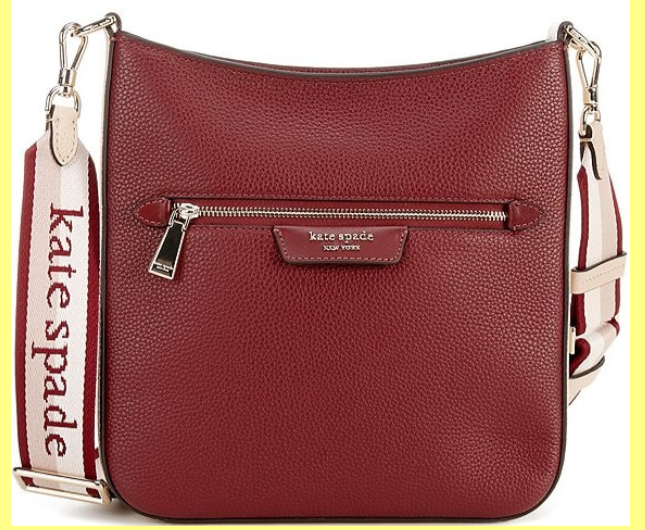

  Image 1 size: (645, 530)



Example 3
conversation_id: 91954de567bf4eba925893d6655466ce
model: gemini-1.5-pro-exp-0827
num_turns: 3
conversation:
  [{'content': 'top image is sketch, bottom is final.', 'role': 'user'}]
  [{'content': 'Okay, I understand. You\'re describing a process where the top image would be a rough sketch of a logo (in this case, possibly a logo featuring the letters "VRIZ"), and the bottom image would be the finalized, polished version of that same logo. \n\nIt seems like you\'re interested in the steps involved in going from a sketch to a final logo. Here\'s a general breakdown of that process:\n\n**1. Sketching and Ideation:**\n\n* **Brainstorming:** This involves understanding the brand, its values, target audience, and desired message.\n* **Rough Sketches:**  Initial ideas are put down on paper (or digitally) in a very loose form. This stage focuses on exploring different concepts, letterforms, and overall shapes. Your example image would fall into this cate

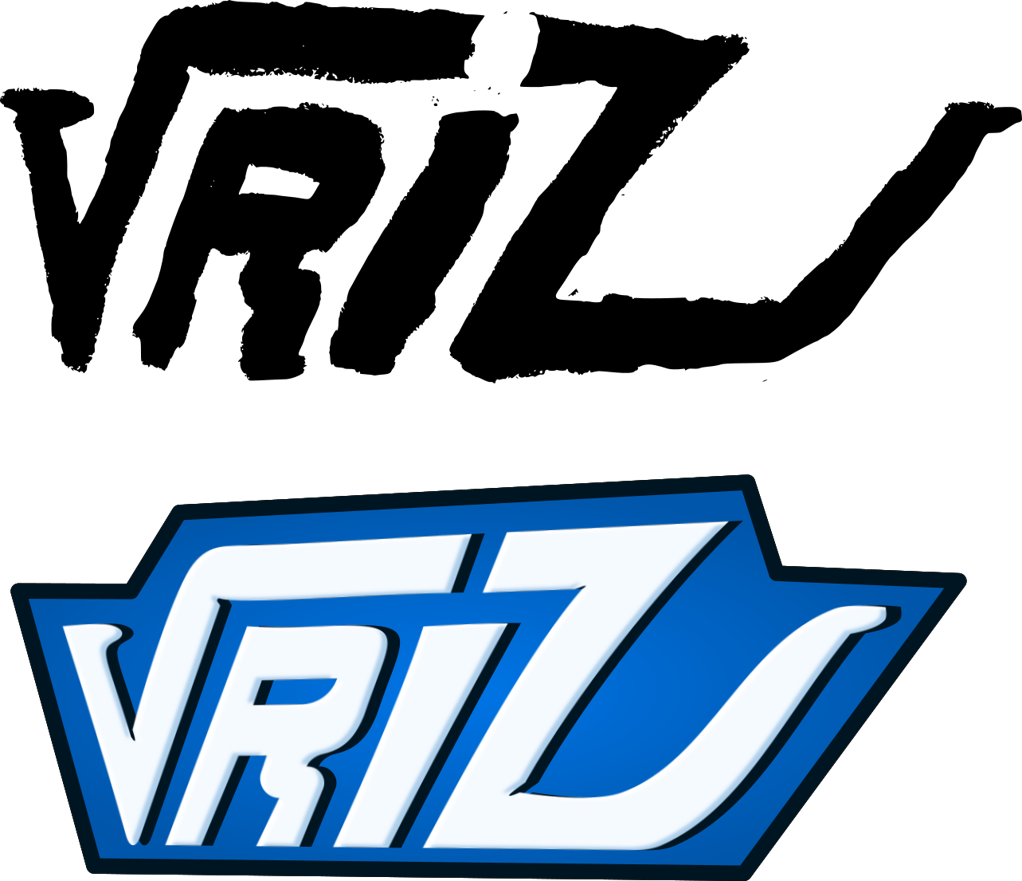

  Image 1 size: (1022, 881)




In [ ]:
from IPython.display import display

# Function to display multiple examples
def show_examples(dataset, num_examples=3):
    """Display multiple examples from the streaming dataset"""
    iterator = iter(dataset['train'])
    
    for i in range(num_examples):
        try:
            data = next(iterator)
            print(f"\n{'='*60}")
            print(f"Example {i+1}")
            print(f"{'='*60}")
            
            # Display metadata (everything except images)
            metadata = {k: v for k, v in data.items() if k != "images"}
            for key, value in metadata.items():
                if key == 'conversation':
                    print(f"{key}:")
                    for turn in value:
                        print(f"  {turn}")
                else:
                    print(f"{key}: {value}")
            
            # Display images - handle different formats
            if 'images' in data and len(data['images']) > 0:
                print(f"\nImages ({len(data['images'])}):")
                for j, img_data in enumerate(data['images']):
                    try:
                        # Case 1: img_data is already a PIL Image
                        if isinstance(img_data, Image.Image):
                            img = img_data
                        # Case 2: img_data is a dict with 'bytes' key
                        elif isinstance(img_data, dict) and 'bytes' in img_data:
                            img = Image.open(io.BytesIO(img_data['bytes']))
                        # Case 3: img_data is bytes directly
                        elif isinstance(img_data, bytes):
                            img = Image.open(io.BytesIO(img_data))
                        # Case 4: img_data is a dict with 'path' key
                        elif isinstance(img_data, dict) and 'path' in img_data:
                            img = Image.open(img_data['path'])
                        else:
                            print(f"  Image {j+1}: Unsupported format - {type(img_data)}")
                            continue
                        
                        display(img)  # Display in notebook
                        print(f"  Image {j+1} size: {img.size}")
                    except Exception as e:
                        print(f"  Image {j+1}: Error loading - {e}")
                        print(f"    Type: {type(img_data)}, Content: {str(img_data)[:100]}")
            
            print("\n")
            
        except StopIteration:
            print(f"Reached end of dataset after {i} examples")
            break

# Show 3 examples (change num_examples to see more)
show_examples(dataset, num_examples=3)

In [ ]:
dataset = dataset["train"].filter(
    lambda batch: [lang in ("English", "Korean") for lang in batch["language"]],
    batched=True,
    batch_size=10_000,
    num_proc=4
) 
# ds_en_ko.save_to_disk("dataset_en_ko") # 
dataset['train'][10]['categories']

In [17]:
import pandas as pd

ds = dataset["train"]

df = pd.DataFrame({
    "model": ds["model"],
    "language": ds["language"],
    "categories": ds["categories"],  # list of dicts
})

In [ ]:
cat_df = pd.json_normalize(df["categories"])

In [21]:
df = pd.concat(
    [df.drop(columns=["categories"]), cat_df],
    axis=1
)

In [27]:
df = df[df["language"].isin(["English", "Korean"])]
df.groupby("language").size().sort_values(ascending=False)

language
English    101306
Korean       2515
dtype: int64